In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

sys.path.append("../src")

# -----------------------------
# Global styling
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

palette = sns.color_palette("Set2") # Custom palette



# 1. Data  Overview
## 1.1 Load Data


In [64]:

%load_ext autoreload
%autoreload 2

import preprocessing as pre

df = pre.load_data()
msg=pre.preprocess_data(df)
df.head(3)
print(msg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64, [False, False, False, False, False, False, False, False, False, False, False], Empty DataFrame
Columns: [date, Usage_kWh, Lagging_Current_Reactive.Power_kVarh, Leading_Current_Reactive_Power_kVarh, CO2(tCO2), Lagging_Current_Power_Factor, Leading_Current_Power_Factor, NSM, WeekStatus, Day_of_week, Load_Type]
Index: [])


## 1.2 Data  Structure

In [15]:
Markdown(f"Data set has **{df.shape[0]}** rows and **{df.shape[1]}** columns.")

Data set has **35040** rows and **11** columns.

# 2. Data Validation
## 2.1 Basic Overview

In [16]:
Markdown(f"{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

None

## 2.2 Checking Missing Value

In [ ]:
# # Checking Missing Value
# print(f"Missing Value: {df.isnull().sum()}")
# col_with_missing = list(df.columns[df.isnull().any()])

# if len(col_with_missing) > 0:
#     print(f"\nColumns with missing value: {col_with_missing}")
# else:
#     print(f"There is no missing value in all columns.")


pre.preprocess_data(df)
# print(missing_value_msg)
# print(duplicated_rows_msg)

pre.test()

## 2.3 Checking Duplicate Value

In [33]:
if(len(df[df.duplicated(keep=False)]) > 0):
  print(f"Number of duplicated rows:{len(df[df.duplicated(keep=False)])}")
else:
  print(f"No duplicated rows found in dataset.")

No duplicated rows found in dataset.


## 2.4 Validating Possible Unique Value and its Range in Numeric Variable

In [34]:
col_num = df.select_dtypes(include=['float64','int64']).columns.tolist()
for col in col_num:
  print(f"Numbers of unique '{col}' value: {df[col].nunique()}, Range:{df[col].max()} - {df[col].min()}")

Numbers of unique 'Usage_kWh' value: 3343, Range:157.18 - 0.0
Numbers of unique 'Lagging_Current_Reactive.Power_kVarh' value: 1954, Range:96.91 - 0.0
Numbers of unique 'Leading_Current_Reactive_Power_kVarh' value: 768, Range:27.76 - 0.0
Numbers of unique 'CO2(tCO2)' value: 8, Range:0.07 - 0.0
Numbers of unique 'Lagging_Current_Power_Factor' value: 5079, Range:100.0 - 0.0
Numbers of unique 'Leading_Current_Power_Factor' value: 3366, Range:100.0 - 0.0
Numbers of unique 'NSM' value: 96, Range:85500 - 0


## 2.5 Validating Possible Unique Value in Object Type Variable

In [35]:
col_cat = df.select_dtypes(include='object').columns.tolist()
for col in col_cat:
  print(f"Numbers of unique '{col}' value: {df[col].nunique()} , Unique category list:{df[col].unique()}")

Numbers of unique 'date' value: 35040 , Unique category list:['01/01/2018 00:15' '01/01/2018 00:30' '01/01/2018 00:45' ...
 '31/12/2018 23:30' '31/12/2018 23:45' '31/12/2018 00:00']
Numbers of unique 'WeekStatus' value: 2 , Unique category list:['Weekday' 'Weekend']
Numbers of unique 'Day_of_week' value: 7 , Unique category list:['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
Numbers of unique 'Load_Type' value: 3 , Unique category list:['Light_Load' 'Medium_Load' 'Maximum_Load']


In [10]:
Markdown(f"As we observe that data type of **date** column should be ***date***, we convert it to date data type.")


As we observe that data type of **date** column should be ***date***, we convert it to date data type.

In [36]:
df['consumed_date'] = pd.to_datetime(df['date'],format='%d/%m/%Y %H:%M')
df.head(5)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,2018-01-01 01:00:00
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,2018-01-01 01:15:00


# 3. Exploratory Analysis
## 3.1 Univariate Analysis - Target Variable
Since we need to predict energy consumption in this steel factory, column '`Usage_kWh`' which indicates industry energy consumption would be our target variable.

In [12]:
# Define target variable
target = 'Usage_kWh'

### 3.1.1 Target Distribution
After target variable is determined, we plot a histogram chart to know its distribution.

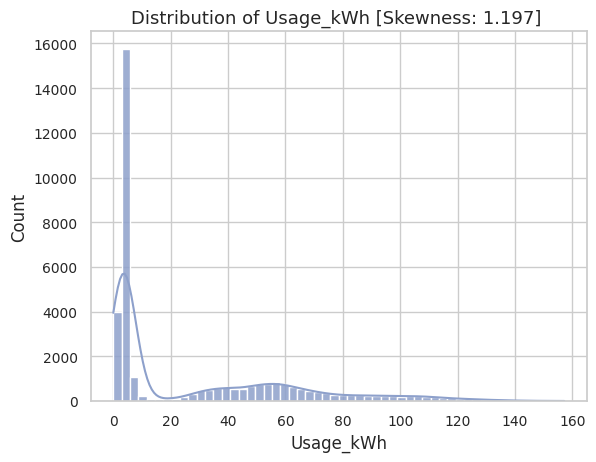

In [13]:
# axes, fig = plt.subplots(1,1, figsize=(12,10))
sns.histplot(data=df[target],
             kde=True,
             color = palette[2],
             edgecolor='white',
             linewidth=1,
             alpha=0.85)
plt.title(f"Distribution of {target} [Skewness: {round(df[target].skew(),3)}] ")
plt.show()

### 3.1.2 Log Transformation

As the target data is highly right-skewed, we applied a log transformation to the target column.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


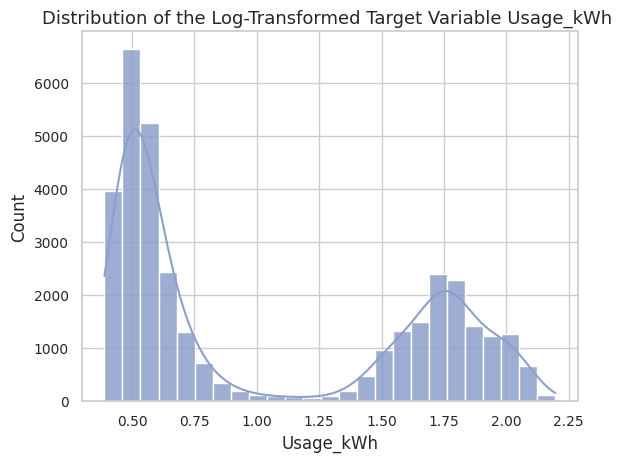

In [14]:
sns.histplot(data=np.log10(df[target]),
             kde=True,
             color = palette[2],
             edgecolor='white',
             linewidth=1,
             alpha=0.85)
plt.title(f"Distribution of the Log-Transformed Target Variable {target} ")
plt.show()

### 3.1.1 Model Recommendation

After the target variable has been determined, we identify the target problem type and then examine suitable machine learning models for that problem type.


In [15]:
if df[target].dtype == 'object' or df[target].nunique() <= 10:
  target_type = 'classification'
else:
  target_type = 'regression'

print(f'Machine Learning/Target Problem Type: {target_type}')

Machine Learning/Target Problem Type: regression


In [16]:
print("Recommended Models :")
if target_type == 'regression':
  corr_target = df[col_num].corr()[target].drop(target)
  high_corr_features = corr_target[abs(corr_target) > 0.7]

  if len(high_corr_features) > 0:
      print("Linear Regression or Ridge/Lasso (high linearity)")
  else:
      print("Random Forest Regressor")
      print("Gradient Boosting Regressor")

Recommended Models :
Linear Regression or Ridge/Lasso (high linearity)


## 3.2 Statistical Summary

After we get a quick statistical summary, we plot the distribution graph to obtain the clear data pattern of numeric features.

In [17]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,consumed_date
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000,2018-07-02 11:52:30
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000,2018-04-02 05:56:15
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000,2018-07-02 11:52:30
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000,2018-10-01 17:48:45
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000,2018-12-31 23:45:00
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317,NaN



## 3.3 Features Distribution

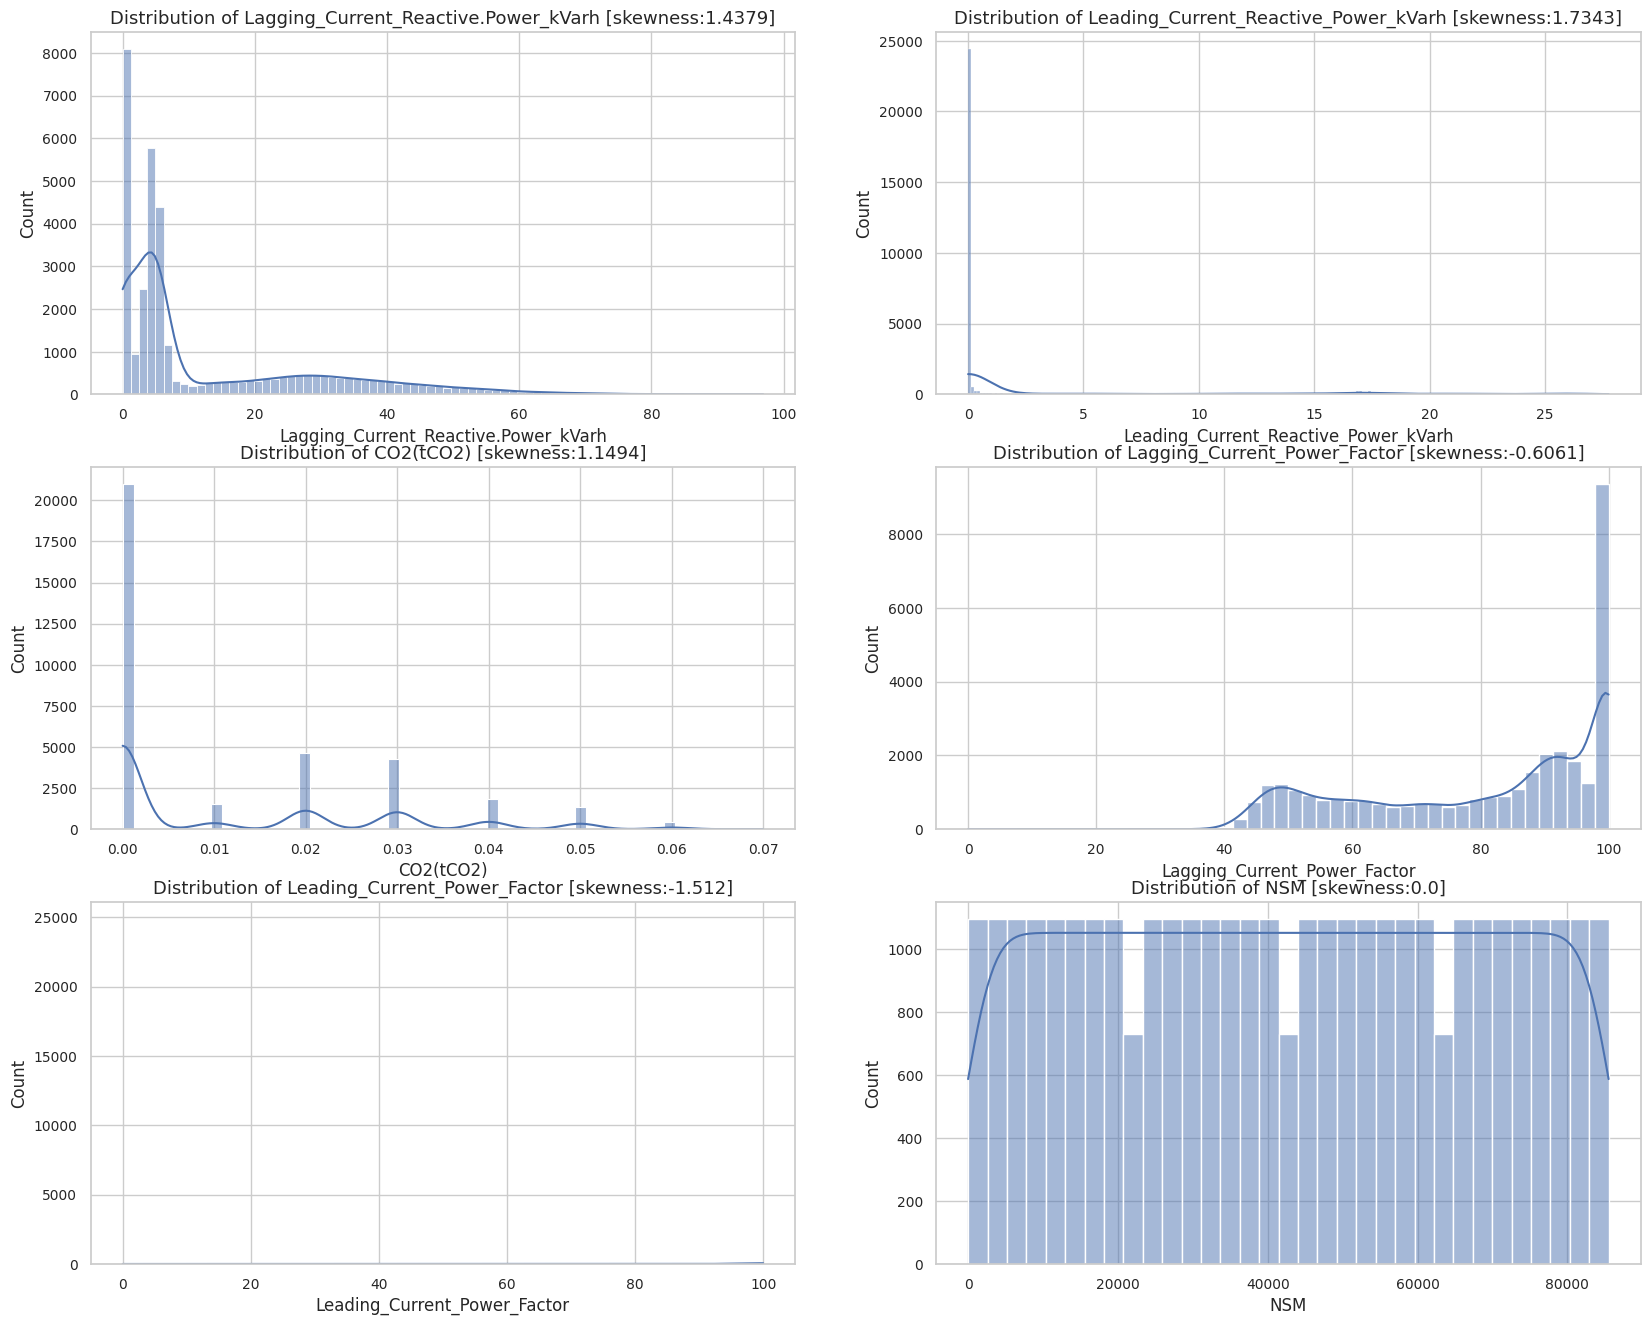

In [18]:
left_skew_feat = []
right_skew_feat = []
plt.figure(figsize=(20,16))

for col in [c for c in col_num if c!= target]:
  plt.subplot(3, 2, col_num.index(col))
  sns.histplot(data=df, x=col,kde=True)
  skewness = round(df[col].skew(),4)
  if skewness != 0.0:
    if skewness < 0.0 :
      left_skew_feat.append(col)
    else:
      right_skew_feat.append(col)
  plt.title(f'Distribution of {col} [skewness:{skewness}]')
plt.show()


In [ ]:
print(f"Left: {left_skew_feat}")
print(f"Right: {right_skew_feat}")

Left: ['Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']
Right: ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)']


As we can observe from the graph above, some features are highly right-skewed, while others are highly left-skewed. We applied a log transformation to the right-skewed features. For features containing very small or negative values, we used the `Yeo–Johnson` transformation via `PowerTransformer` to reduce skewness, as it can handle both positive and negative values.

### 3.3.1 Log Transformation to Right-Skewed Features

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


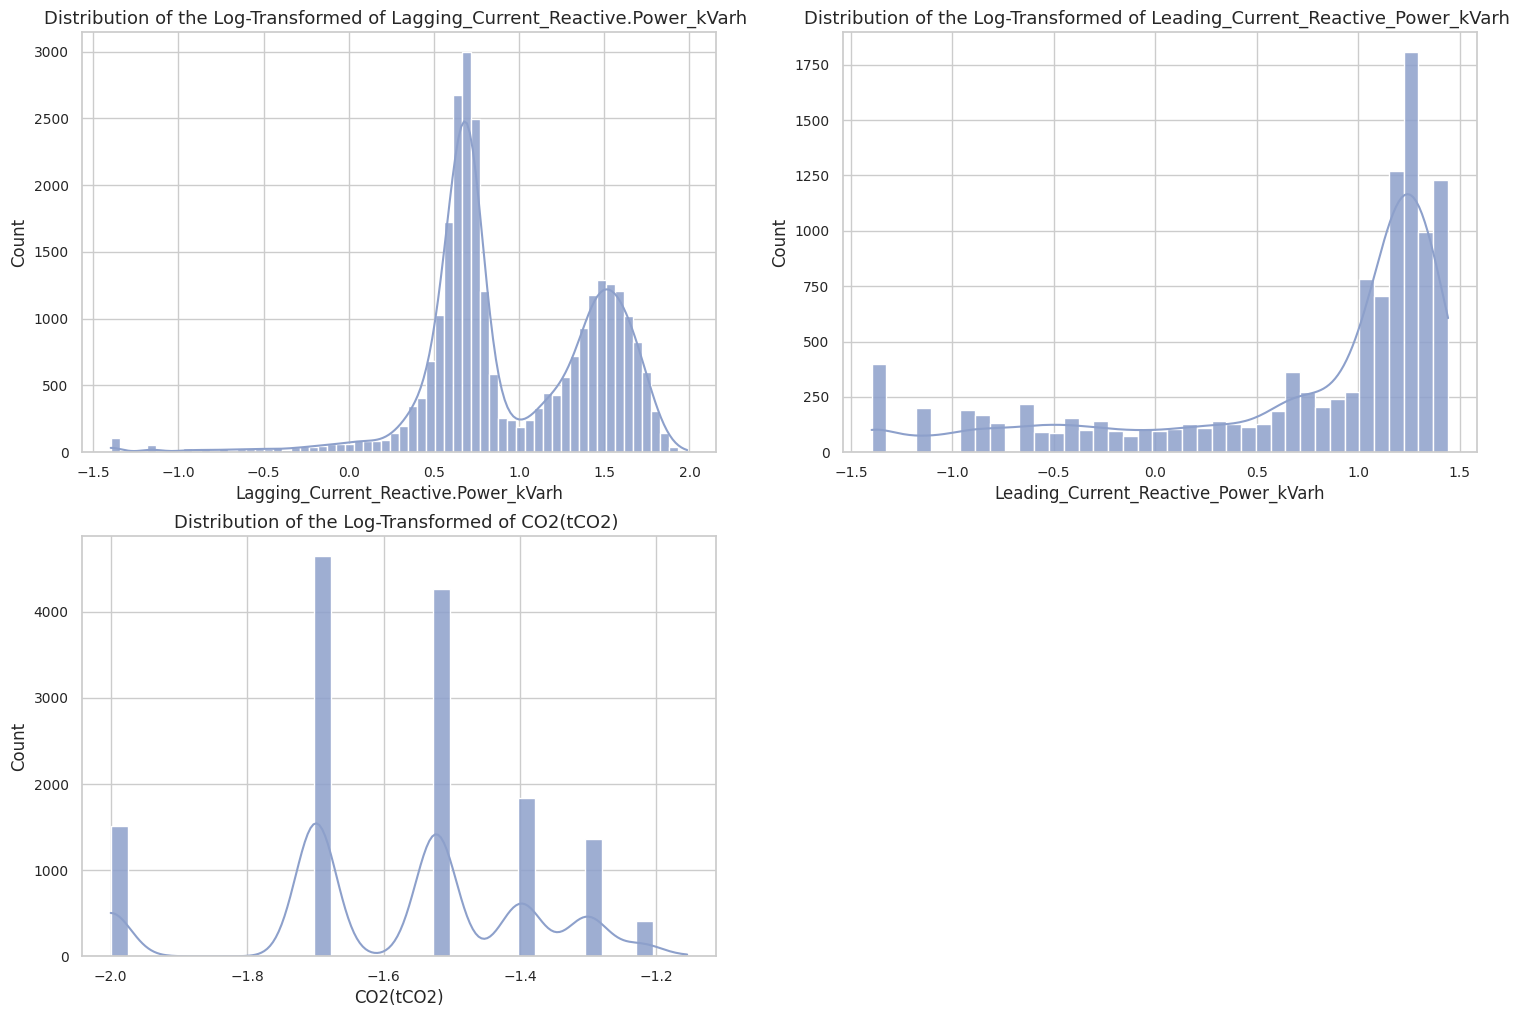

In [ ]:
plt.figure(figsize=(18,12))
for col in right_skew_feat:
  plt.subplot(2,2,right_skew_feat.index(col)+1)
  sns.histplot(data=np.log10(df[col]),
              kde=True,
              color = palette[2],
              edgecolor='white',
              linewidth=1,
              alpha=0.85)
  plt.title(f"Distribution of the Log-Transformed of {col} ")
plt.show()

### 3.3.2 Yeo-Johnson Transformation to Left-Skewed Features

However, for left-skewed features, we cannot apply the Yeo-Johnson transformation on the full dataset, as it tries to find the optimal λ parameter — the value that makes the resulting distribution as Gaussian as possible. This causes **data leakage**, so we should split the data first and then apply the transformation on the **training dataset only**.